In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from pathlib import Path
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm 
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')



path0 = Path("/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp")
path1 = Path("/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp001")
path2 = Path("/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002")
path3 = Path('/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop')
path4 = Path('/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1')

paths = [path0, path1, path2, path3, path4]

TAU = 200

SCALE = 0.11
INTERVAL = 4

tau_frame = int(TAU/INTERVAL)
XLIM = (-20,20)

OUTPUT_PATH = f"/Users/sasakinozomu/code/MTCargo_analysis/notebooks/figures/PDF_tau{TAU}s"

os.makedirs(OUTPUT_PATH, exist_ok=True)

def getPDF(tau):
    PDFxs = []
    PDFys = []
    particleN = []

    for path in paths:
        dfp = path / "beads_tracks.csv"
        df = pd.read_csv(dfp)
        PDFx = dpm.PDF(df, tau, scale = SCALE, xy = 'x')
        PDFy = dpm.PDF(df, tau, scale = SCALE, xy = 'y')
        PDFxs.append(PDFx)
        PDFys.append(PDFy)
        unique = np.unique(df['particle'])
        print(unique)
        particle_num = unique.shape[0]
        particleN.append(particle_num)

    return PDFxs, PDFys, particleN

def hist(PDFx, PDFy, ax):
    binsx = np.histogram_bin_edges(PDFx, bins='sqrt')
    binsy = np.histogram_bin_edges(PDFy, bins='sqrt')
    ax.hist(PDFx, binsx[:-1], alpha = 0.5, label = '$\\Delta$x')
    ax.hist(PDFy, binsy[:-1], alpha = 0.5, label = '$\\Delta$y')

PDFx, PDFy, particleN = getPDF(tau_frame)

[ 5 10]
[1 3 4 5 6 7]
[0 1 3 4]
[ 2  4  5  6  7 39]
[  3   4  26  97 115 256 360 366 518 637 697]


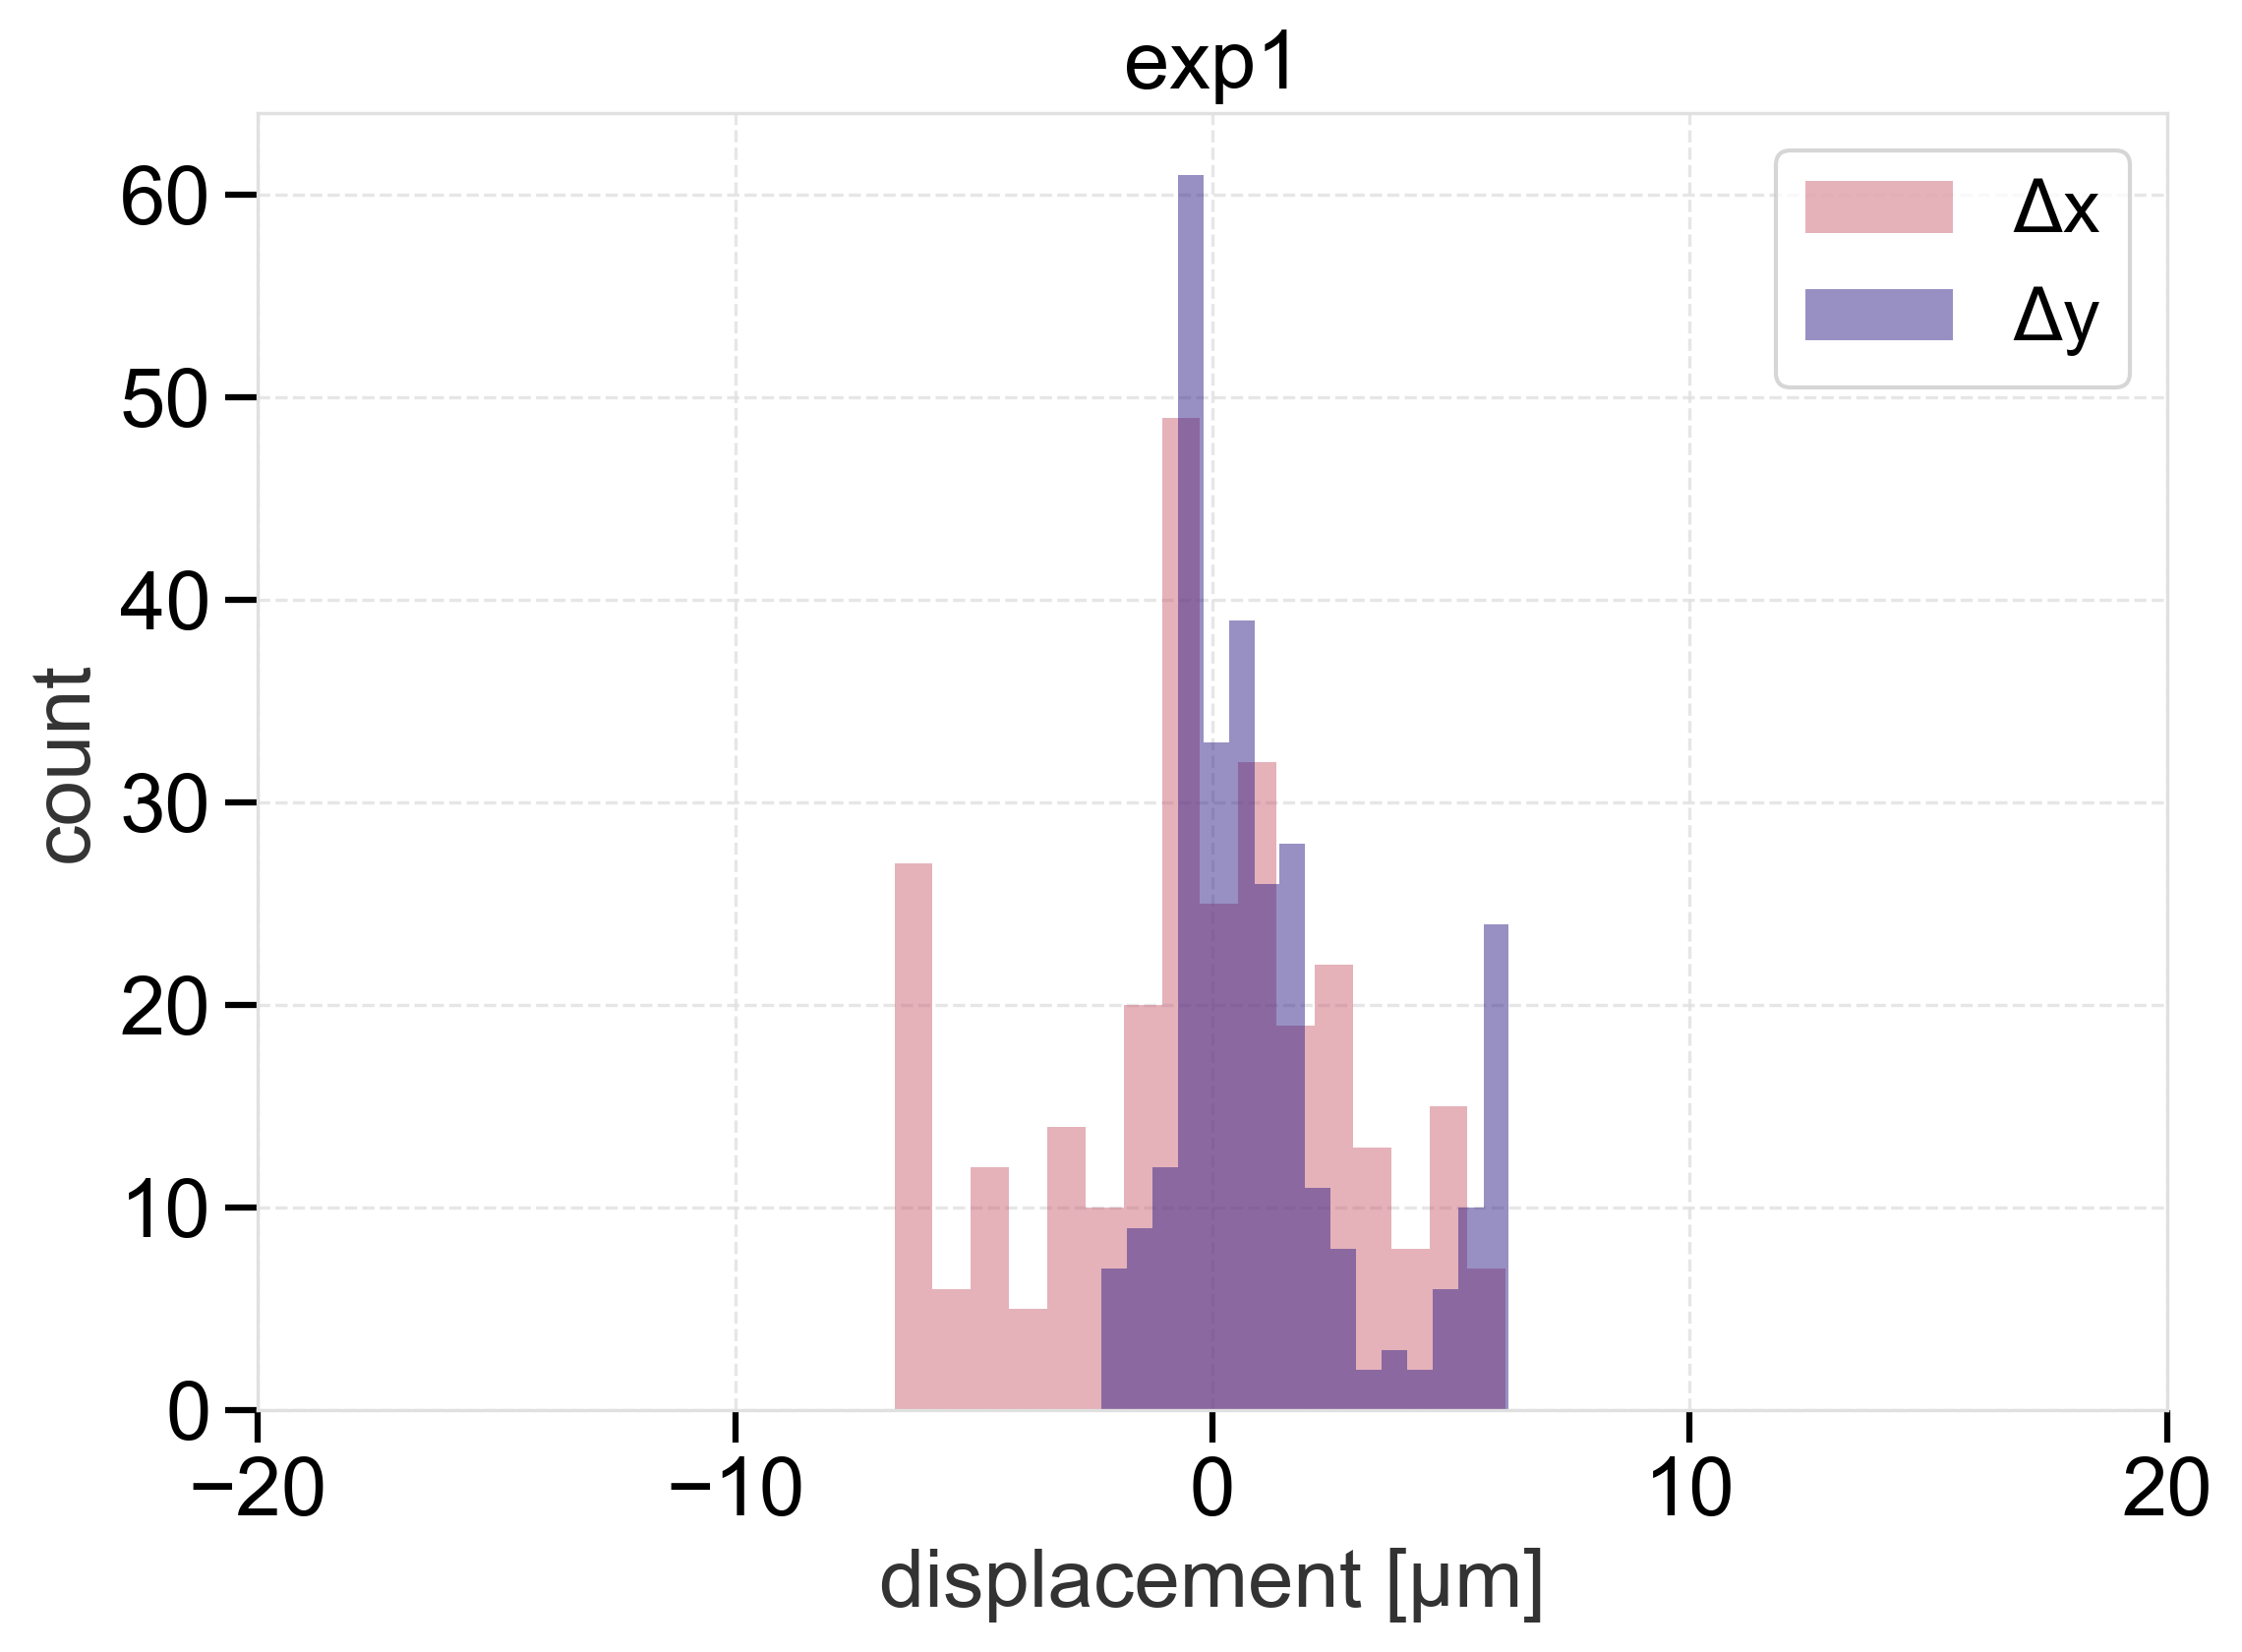

In [2]:
i = 0

fig, ax = plt.subplots()
hist(PDFx[i], PDFy[i], ax)
ax.legend()
ax.set(xlabel='displacement [\u03bcm]',
       ylabel = 'count',
       xlim = XLIM,
       title = f'exp{i+1}')

fig.savefig(f'{OUTPUT_PATH}/exp{i+1}.png')
fig.savefig(f'{OUTPUT_PATH}/exp{i+1}.pdf')

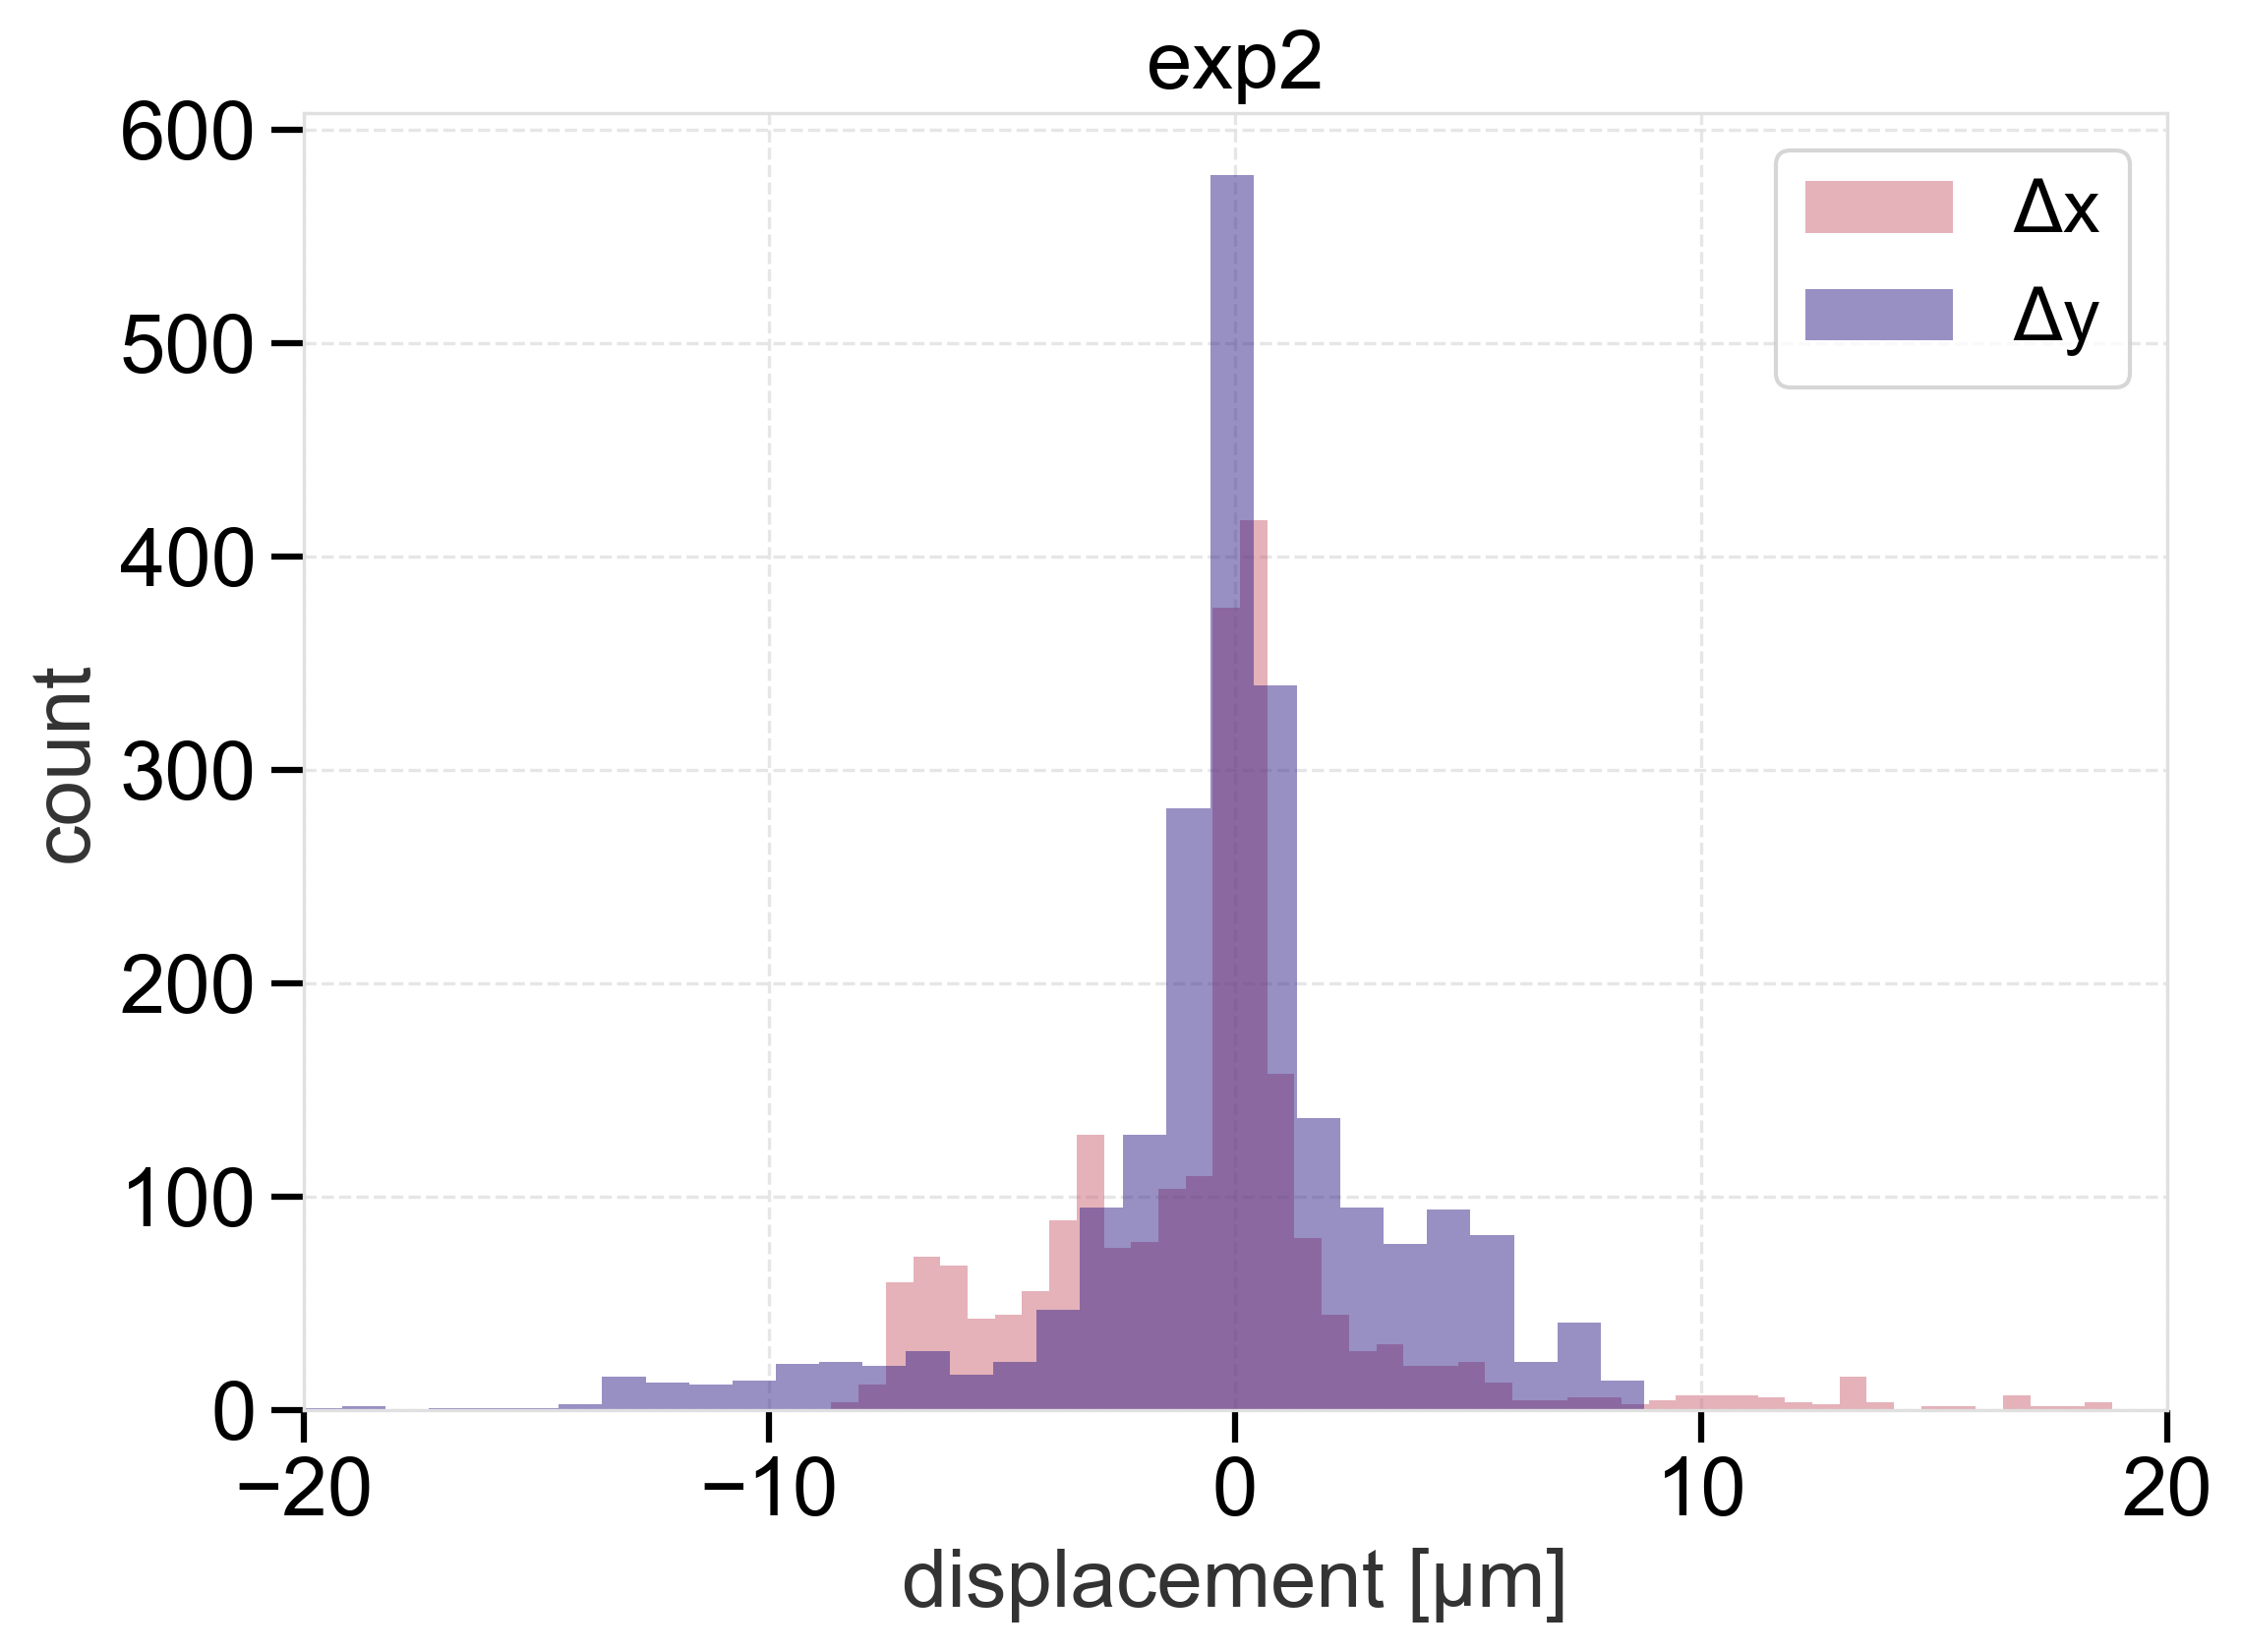

In [3]:
i = 1

fig, ax = plt.subplots()
hist(PDFx[i], PDFy[i], ax)
ax.legend()
ax.set(xlabel='displacement [\u03bcm]',
       ylabel = 'count',
       xlim = XLIM,
       title = f'exp{i+1}')

fig.savefig(f'{OUTPUT_PATH}/exp{i+1}.png')
fig.savefig(f'{OUTPUT_PATH}/exp{i+1}.pdf')

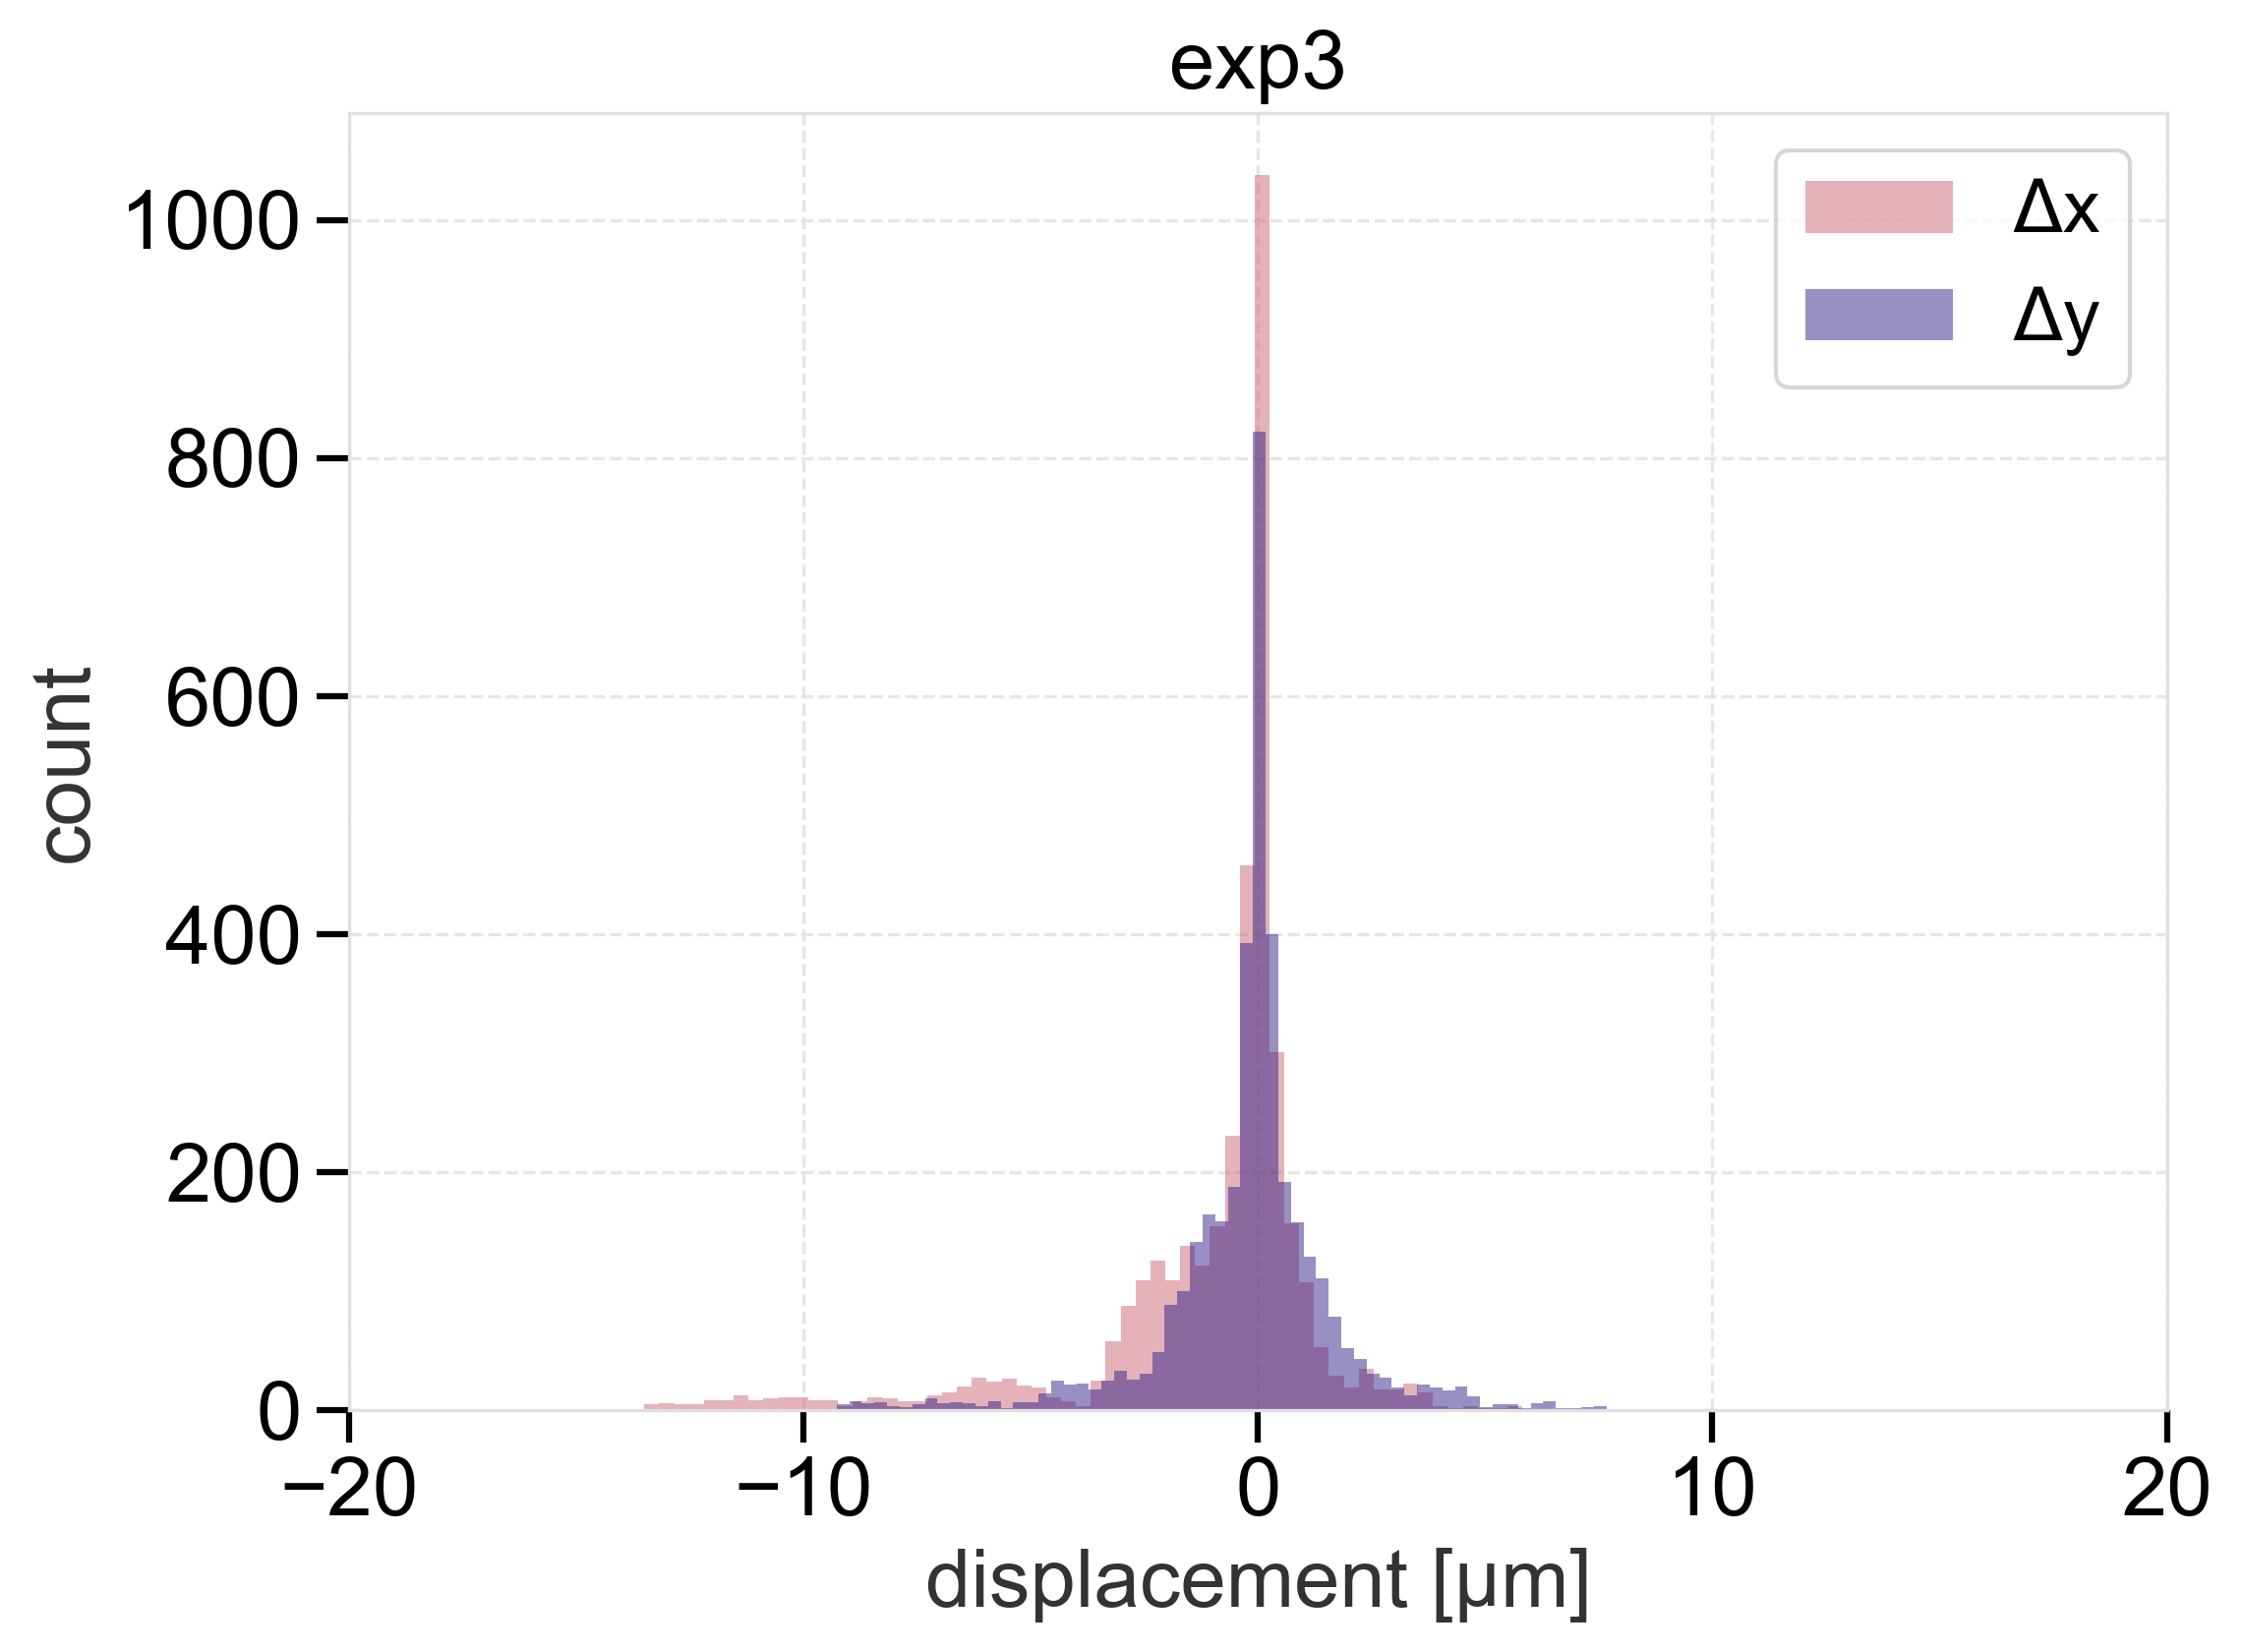

In [4]:
i = 2

fig, ax = plt.subplots()
hist(PDFx[i], PDFy[i], ax)
ax.legend()
ax.set(xlabel='displacement [\u03bcm]',
       ylabel = 'count',
       xlim = XLIM,
       title = f'exp{i+1}')

fig.savefig(f'{OUTPUT_PATH}/exp{i+1}.png')
fig.savefig(f'{OUTPUT_PATH}/exp{i+1}.pdf')

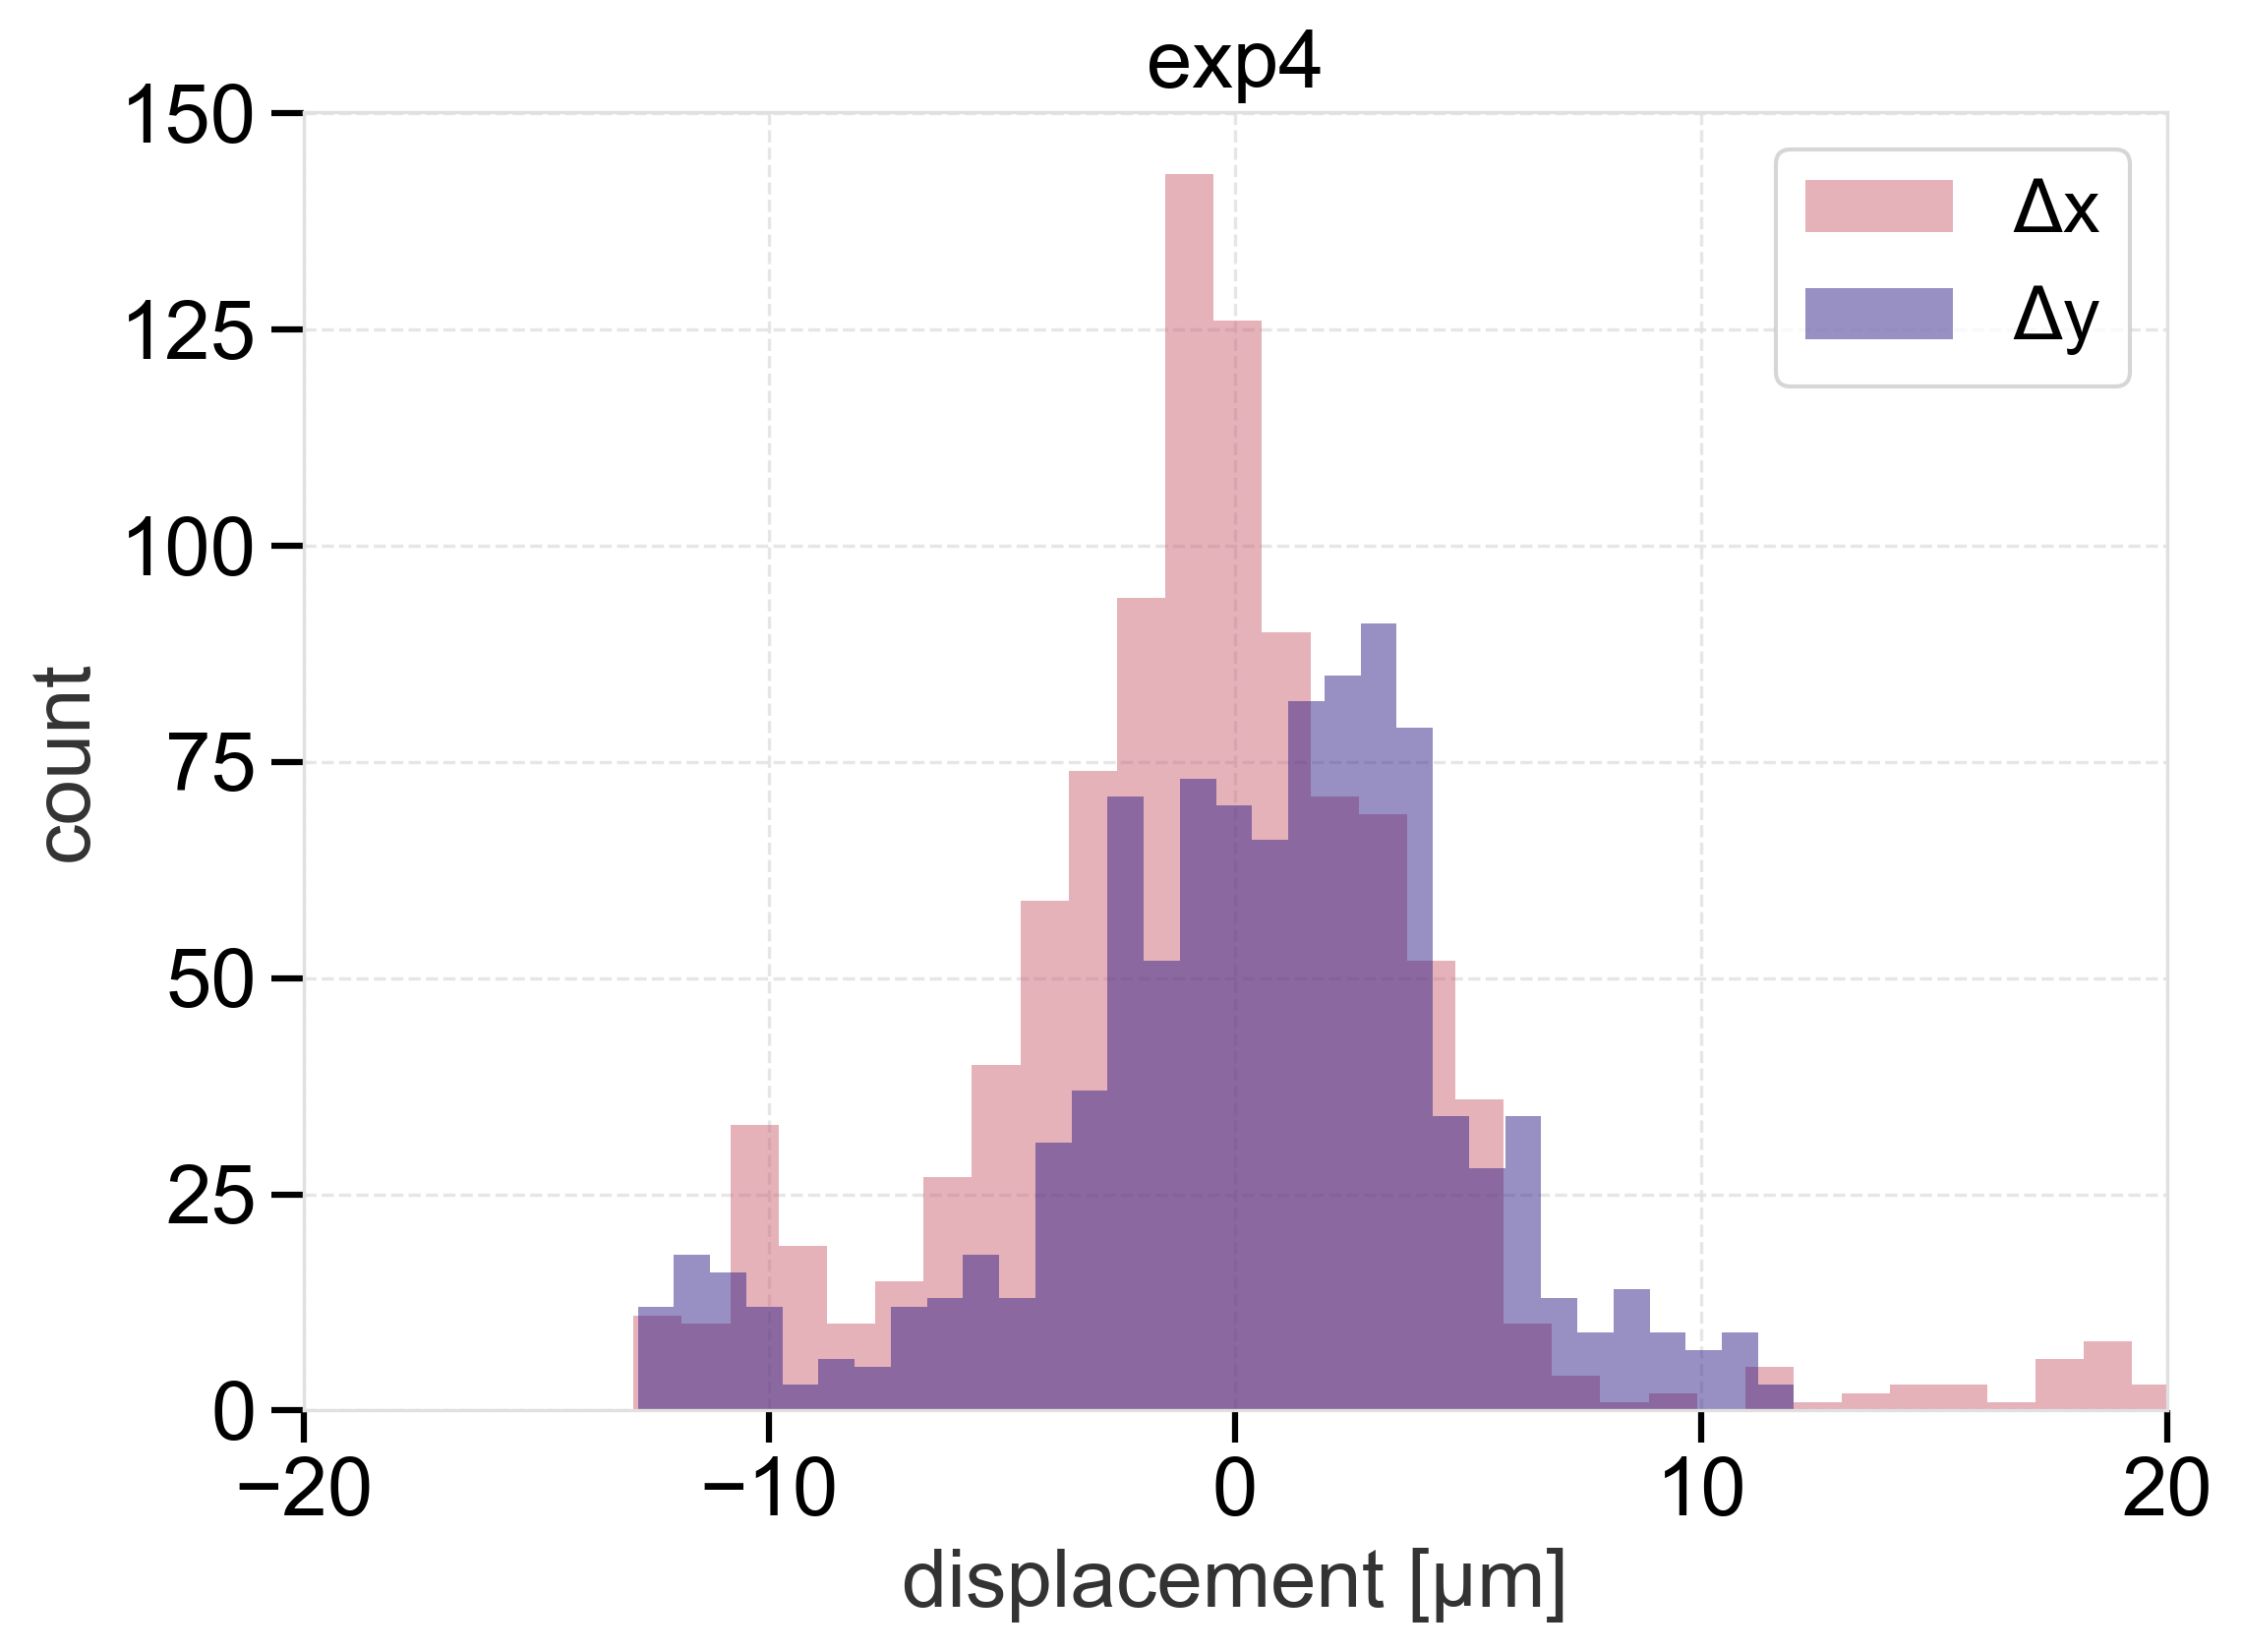

In [5]:
i = 3

fig, ax = plt.subplots()
hist(PDFx[i], PDFy[i], ax)
ax.legend()
ax.set(xlabel='displacement [\u03bcm]',
       ylabel = 'count',
       xlim = XLIM,
       title = f'exp{i+1}')

fig.savefig(f'{OUTPUT_PATH}/exp{i+1}.png')
fig.savefig(f'{OUTPUT_PATH}/exp{i+1}.pdf')

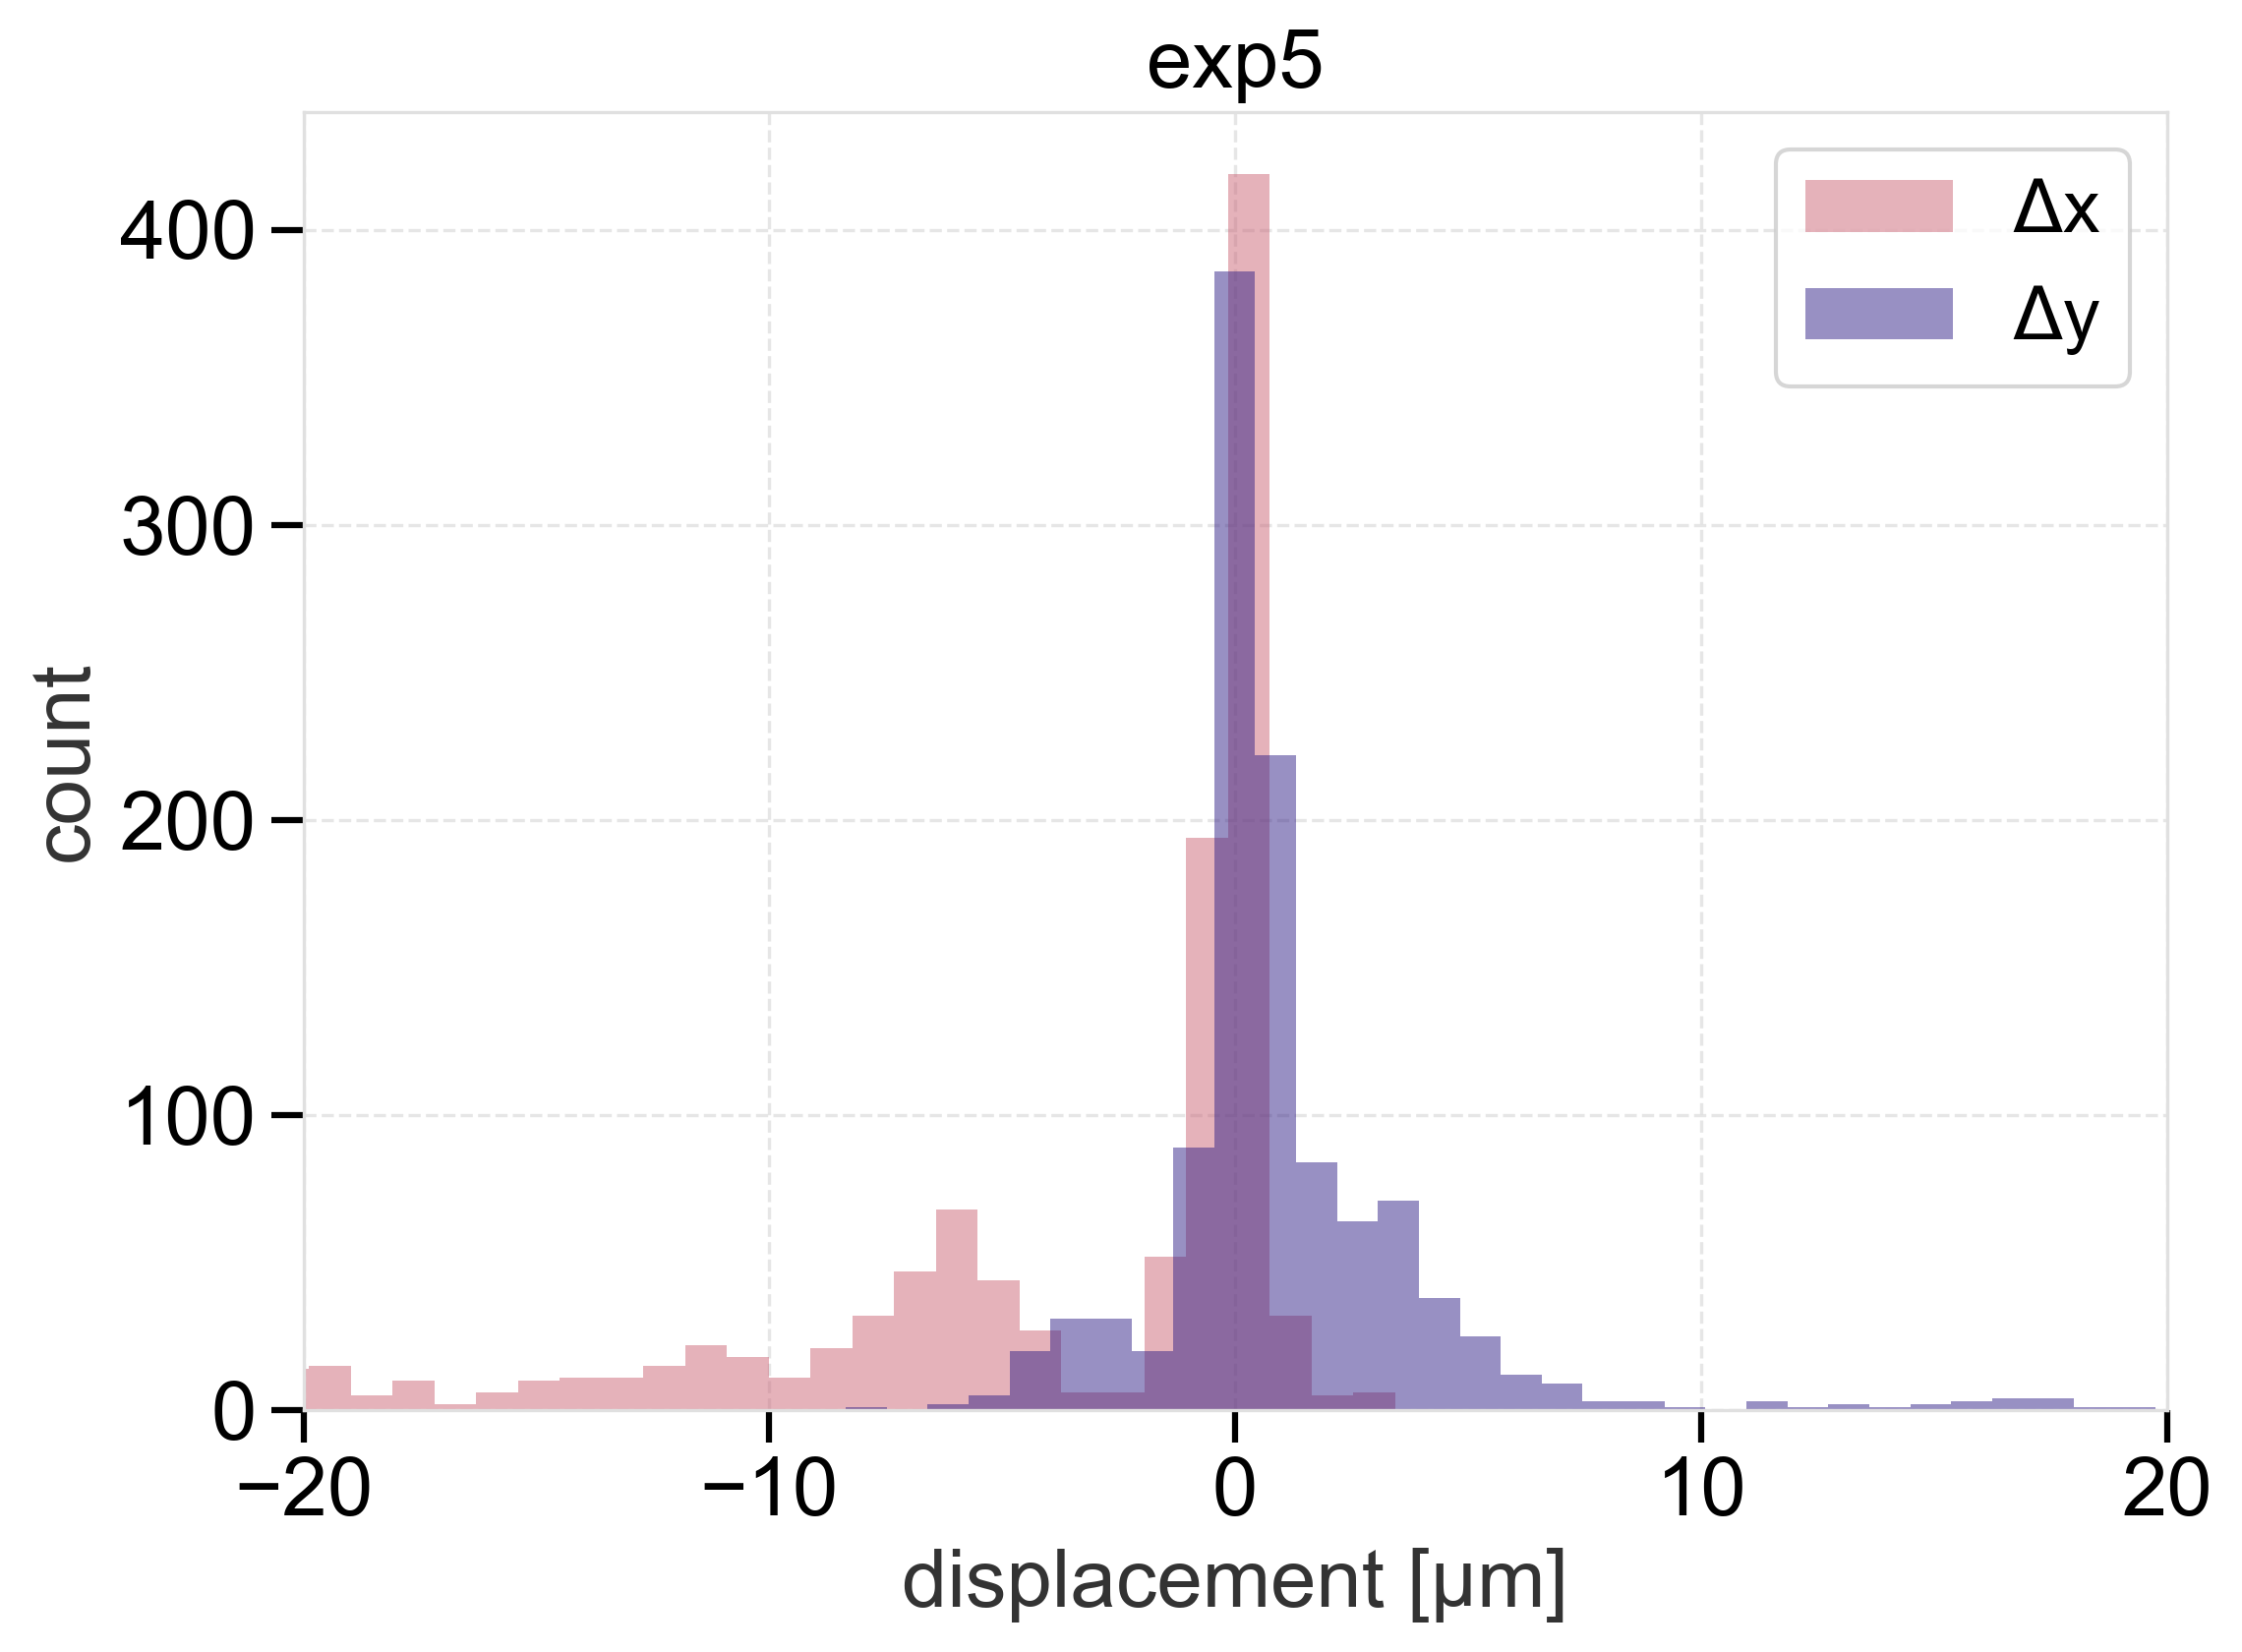

In [6]:
i = 4

fig, ax = plt.subplots()
hist(PDFx[i], PDFy[i], ax)
ax.legend()
ax.set(xlabel='displacement [\u03bcm]',
       ylabel = 'count',
       xlim = XLIM,
       title = f'exp{i+1}')

fig.savefig(f'{OUTPUT_PATH}/exp{i+1}.png')
fig.savefig(f'{OUTPUT_PATH}/exp{i+1}.pdf')

In [7]:
def getPDF_concat(tau):
    i = 0
    for path in paths:
       dfp = path / "beads_tracks.csv"
       if i==0:
           df = cv.cal(pd.read_csv(dfp), scale=SCALE, frame_interval=INTERVAL)
           i+=1
           continue
       df0 = cv.cal(pd.read_csv(dfp), scale=SCALE, frame_interval=INTERVAL)
       df0['particle'] += 10000 * i
       df = pd.concat((df, df0))
       i+=1
        
    PDFx = dpm.PDF(df, tau, scale = SCALE, xy = 'x')
    PDFy = dpm.PDF(df, tau, scale = SCALE, xy = 'y')

    return PDFx, PDFy

PDFx_conc, PDFy_conc = getPDF_concat(tau_frame)

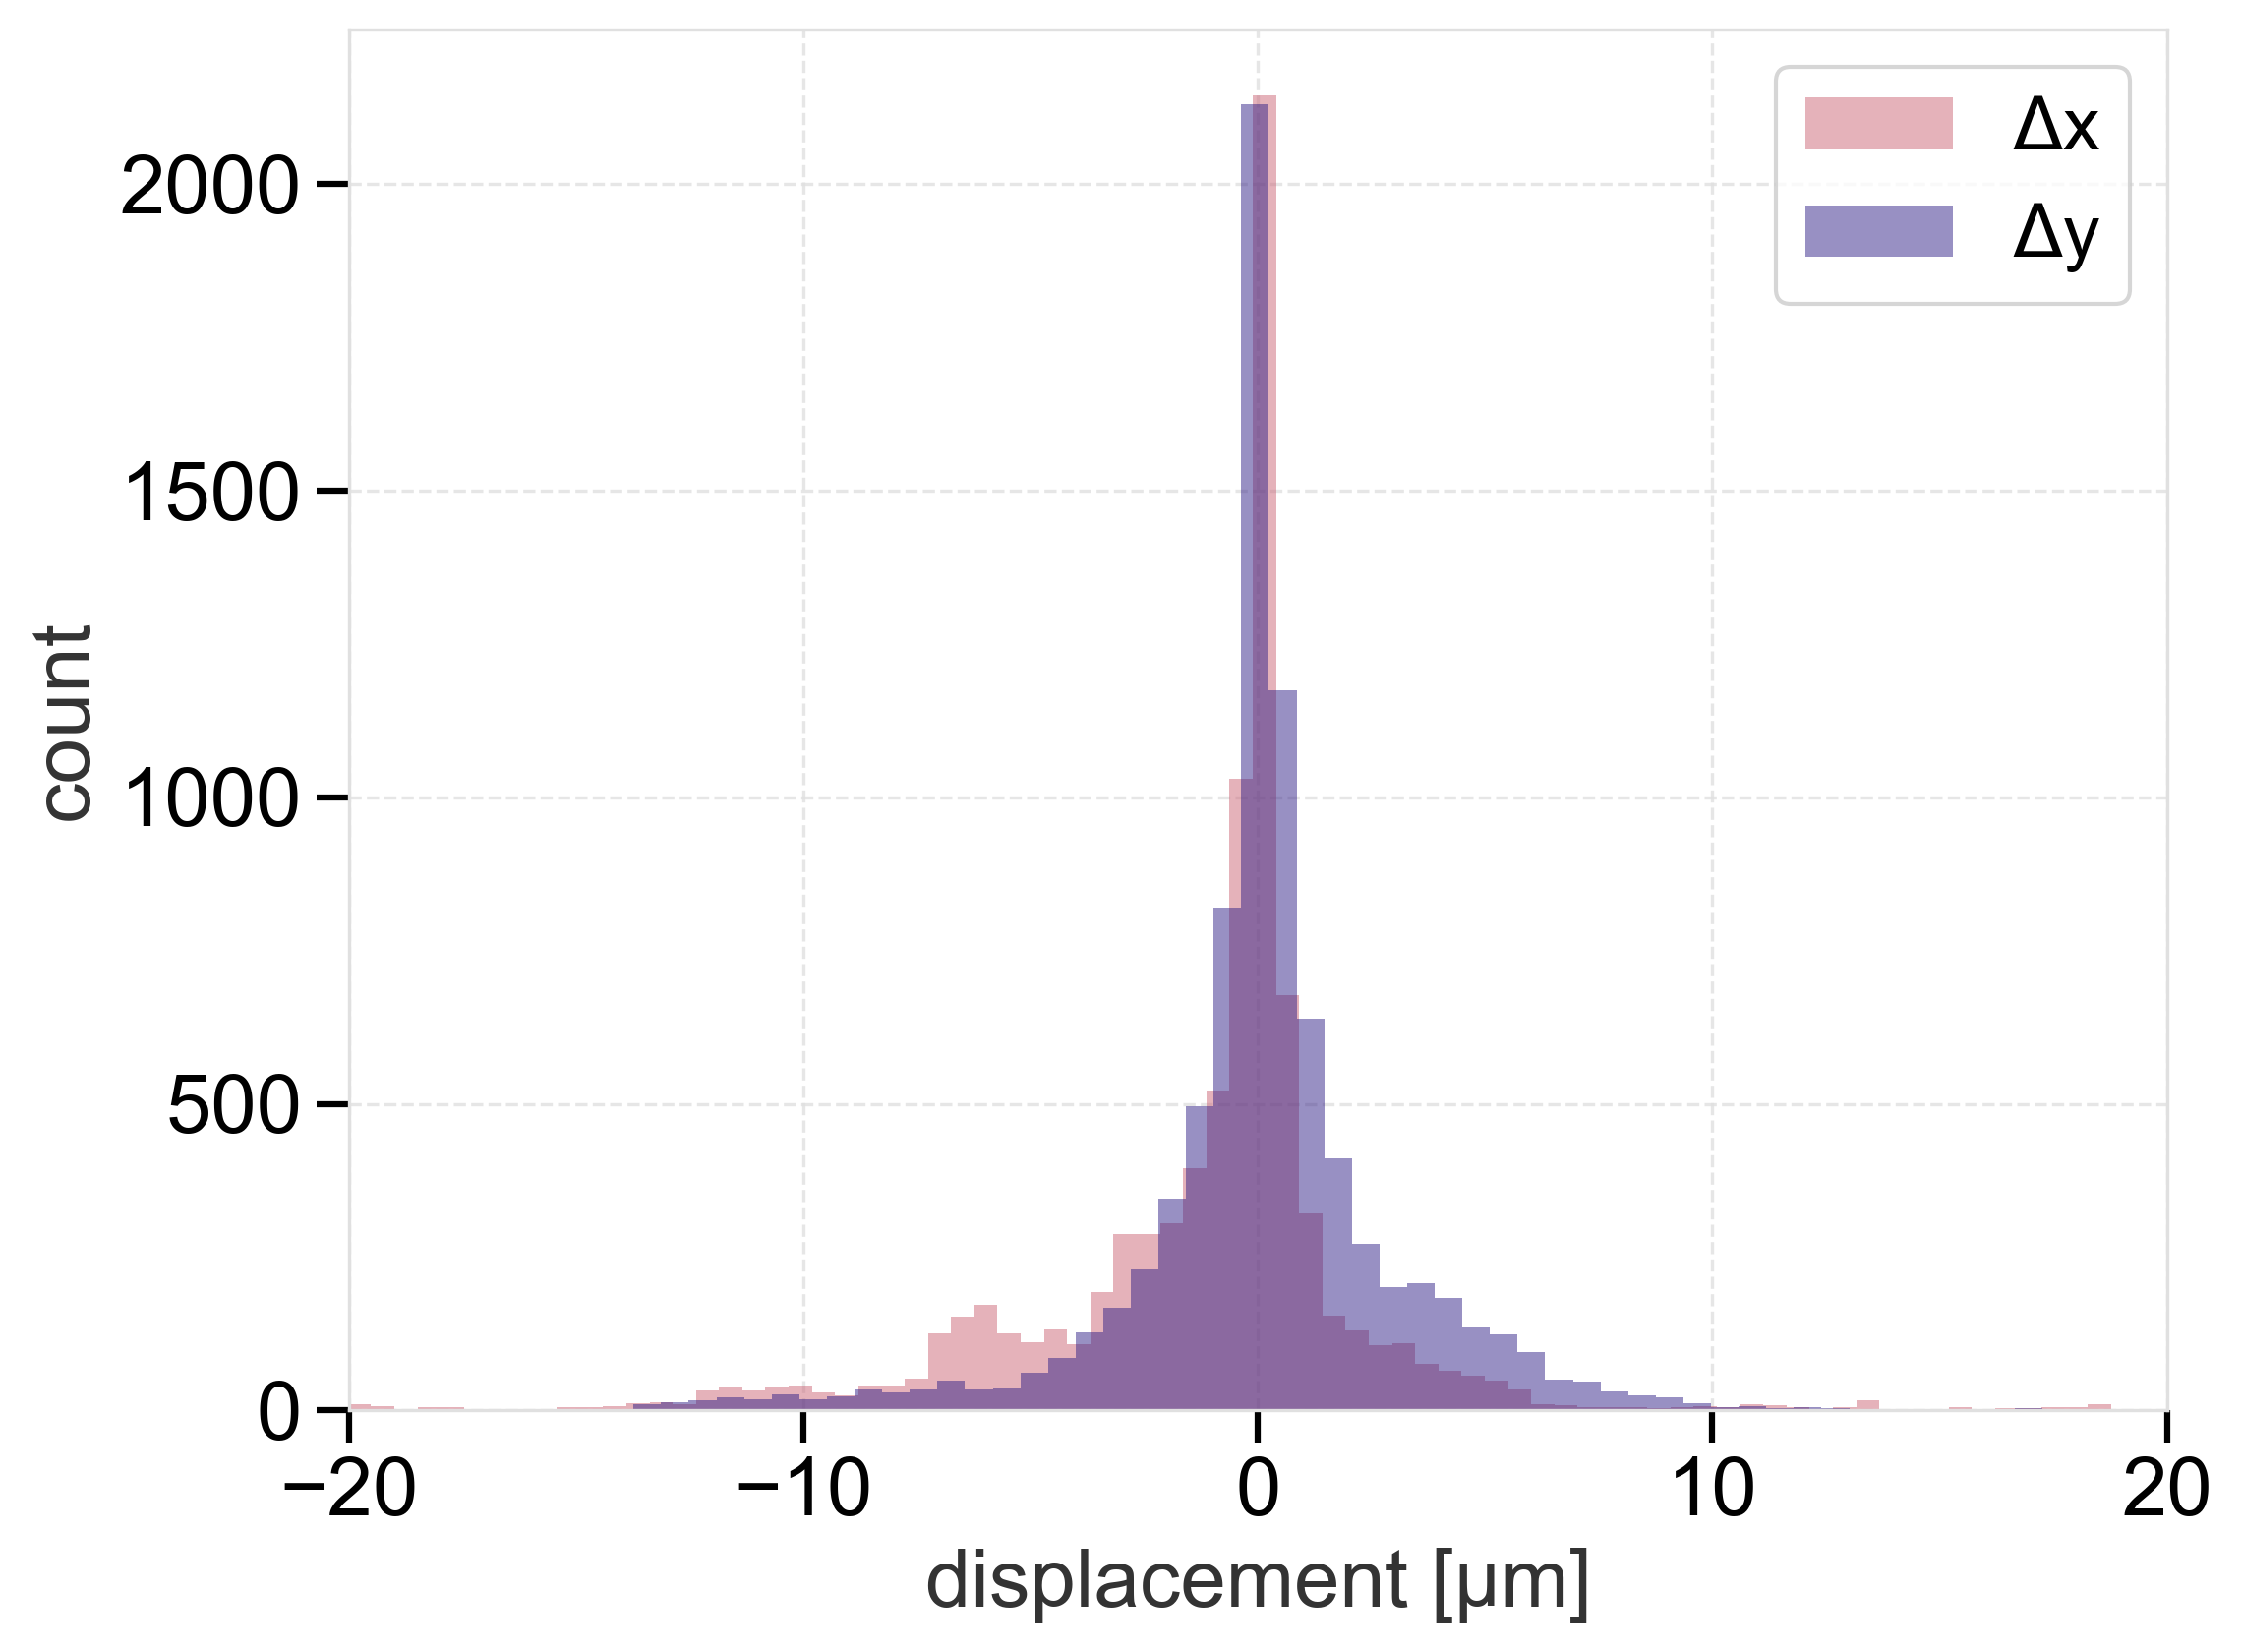

In [8]:
fig, ax = plt.subplots()
hist(PDFx_conc, PDFy_conc, ax)
ax.legend()
ax.set(xlabel='displacement [\u03bcm]',
       ylabel = 'count',
       xlim = XLIM)

fig.savefig(f'{OUTPUT_PATH}/ALLexp.png')
fig.savefig(f'{OUTPUT_PATH}/ALLexp.pdf')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm 
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')

mypass = '/mnt/ssd_data/Sasaki/MTSingleBeads'
mypass = '/Volumes/My Passport/Sasaki/MTsingleBeads'

